# Приклад виконання роботи в Python

Середнє значення: -0.0049184275271582315
Енергія: 27.17125183458844
Потужність: 0.679281295864711
RMS: 0.8241852315254812


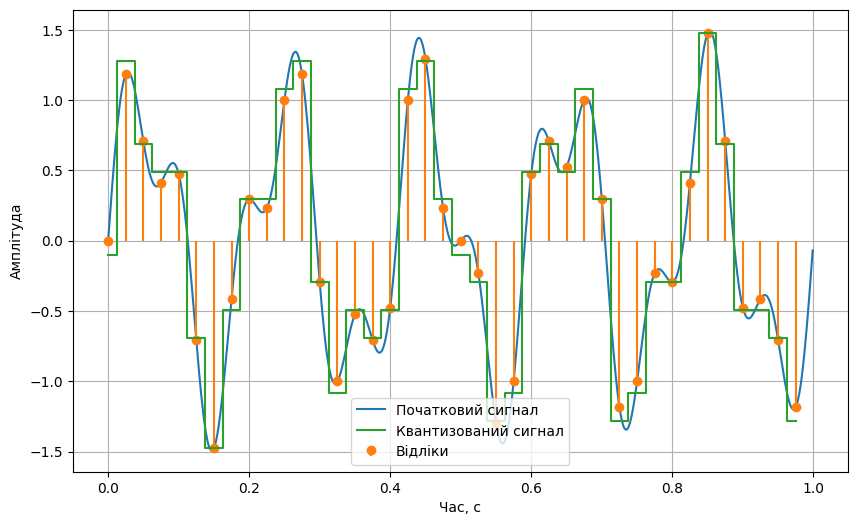

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Параметри початкового сигналу
t = np.linspace(0, 1, 1000, endpoint=False)
x = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 12 * t)

# Дискретизація
fs = 40
ts = np.arange(0, 1, 1 / fs)
xs = np.sin(2 * np.pi * 5 * ts) + 0.5 * np.sin(2 * np.pi * 12 * ts)

# Квантування
levels = 16
xmin, xmax = xs.min(), xs.max()
dq = (xmax - xmin) / (levels - 1)
xq = np.round((xs - xmin) / dq) * dq + xmin

# Часові характеристики
mean_value = np.mean(xq)
energy = np.sum(xq ** 2)
power = np.mean(xq ** 2)
rms = np.sqrt(power)

print("Середнє значення:", mean_value)
print("Енергія:", energy)
print("Потужність:", power)
print("RMS:", rms)

# Графіки
plt.figure(figsize=(10, 6))
plt.plot(t, x, label="Початковий сигнал")
plt.stem(ts, xs, linefmt='C1-', markerfmt='C1o', basefmt=' ', label="Відліки")
plt.step(ts, xq, where='mid', label="Квантизований сигнал")
plt.grid(True)
plt.xlabel("Час, с")
plt.ylabel("Амплітуда")
plt.legend()
plt.show()


# Реалізація завдань

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import HTML
from scipy import signal

# --- ФУНКЦІЇ ---
def calculate_metrics(signal_values):
    mean_val = np.mean(signal_values)
    energy = np.sum(signal_values ** 2)
    power = np.mean(signal_values ** 2)
    rms = np.sqrt(power)
    return mean_val, energy, power, rms

def get_plot_base64(t_full, x_full, ts, xq, title=''):
    plt.figure(figsize=(7, 4))
    plt.plot(t_full, x_full, label="Оригінал", alpha=0.5, color='green')
    plt.step(ts, xq, where='mid', label="Квант.", color='orange', linewidth=1.5)
    plt.title(title, fontsize=9)
    plt.legend(prop={'size': 7})
    plt.grid(True, alpha=0.3)

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close()
    return f'<img src="data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}" width="200">'

def process_signal(label, fs=40, levels=32, freqs=[5], amps=[1], const=0, noise=0, sig_type='sine'):
    t_full = np.linspace(0, 1, 1000, endpoint=False)

    # Створення сигналу (синус або прямокутник)
    def generate(time_array):
        res = np.zeros_like(time_array)
        if sig_type == 'sine':
            for f, a in zip(freqs, amps):
                res += a * np.sin(2 * np.pi * f * time_array)
        elif sig_type == 'square':
            res = amps[0] * signal.square(2 * np.pi * freqs[0] * time_array)

        res += const
        if noise > 0:
            res += np.random.normal(0, noise, size=time_array.shape)
        return res

    x_full = generate(t_full)

    # Дискретизація
    ts = np.arange(0, 1, 1 / fs)
    xs = generate(ts)

    # Квантування
    xmin, xmax = xs.min(), xs.max()
    if xmax == xmin: xmax += 1e-6
    dq = (xmax - xmin) / (levels - 1)
    xq = np.round((xs - xmin) / dq) * dq + xmin

    # Розрахунок метрик
    m_orig, e_orig, p_orig, r_orig = calculate_metrics(x_full)
    m_val, eng, pwr, rms = calculate_metrics(xq)

    # Похибка - середньоквадратична помилка між оригіналом (у точках дискр.) та квантованим сигналом
    mse_error = np.mean((xs - xq)**2)

    return {
        "Варіант": label,
        "Параметри": f"fs={fs}, L={levels}, noise={noise}",
        "Mean": round(m_val, 4),
        "RMS (Quant)": round(rms, 4),
        "RMS (Orig)": round(r_orig, 4),
        "Energy": round(eng, 4),
        "Power": round(pwr, 4),
        "MSE Error": round(mse_error, 6),
        "Графік": get_plot_base64(t_full, x_full, ts, xq, label)
    }

,Варіант,Параметри,Mean,RMS (Quant),RMS (Orig),Energy,Power,MSE Error,Графік
0,Еталон (5 Гц),"fs=1000, L=32, noise=0",-0.0000,0.7091,0.7071,502.8512,0.5029,0.000332,
1,Вар 1: Сигнал 10 Гц,"fs=1000, L=32, noise=0",-0.0001,0.7103,0.7071,504.5161,0.5045,0.000392,
2,Вар 2: fs=12,"fs=12, L=32, noise=0",0.0054,0.7055,0.7071,5.9729,0.4977,0.000268,
3,Вар 2: fs=25,"fs=25, L=32, noise=0",-0.0012,0.7056,0.7071,12.4476,0.4979,0.000198,
4,Вар 2: fs=100,"fs=100, L=32, noise=0",-0.0000,0.7051,0.7071,49.7190,0.4972,0.000350,
5,Вар 3: рівнів=4,"fs=40, L=4, noise=0",-0.0000,0.8819,0.7071,31.1111,0.7778,0.070671,
6,Вар 3: рівнів=8,"fs=40, L=8, noise=0",0.0000,0.7143,0.7071,20.4082,0.5102,0.005128,
7,Вар 3: рівнів=16,"fs=40, L=16, noise=0",0.0000,0.7211,0.7071,20.8000,0.5200,0.001455,
8,Вар 3: рівнів=32,"fs=40, L=32, noise=0",-0.0000,0.6926,0.7071,19.1883,0.4797,0.000701,
9,Вар 4: Signal + const,"fs=40, L=32, noise=0",3.0000,3.0789,3.0822,379.1883,9.4797,0.000701,

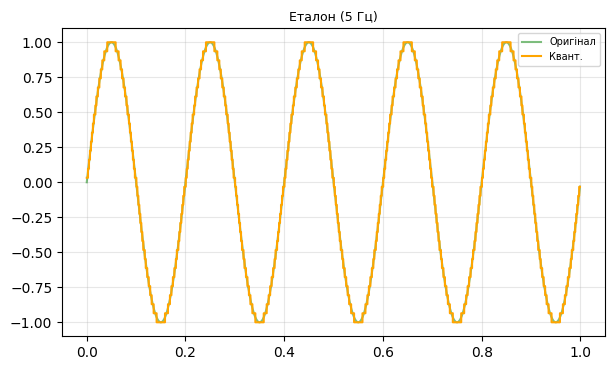
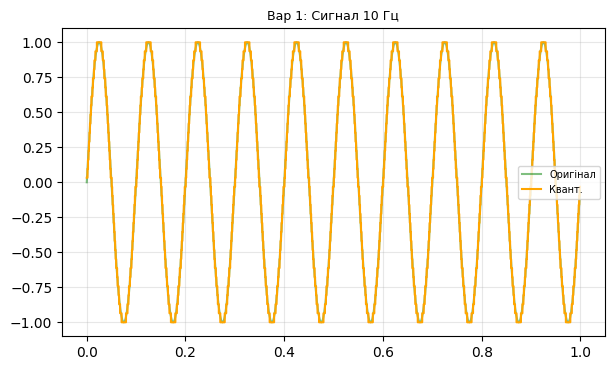
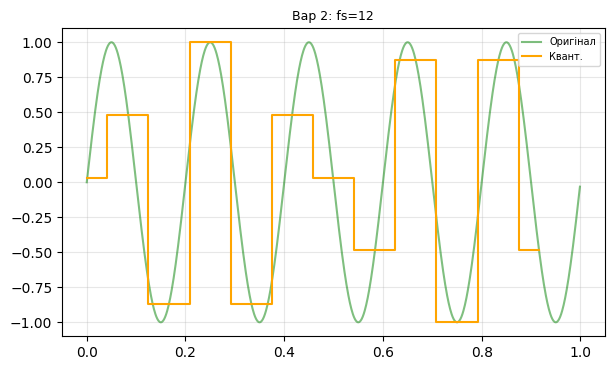
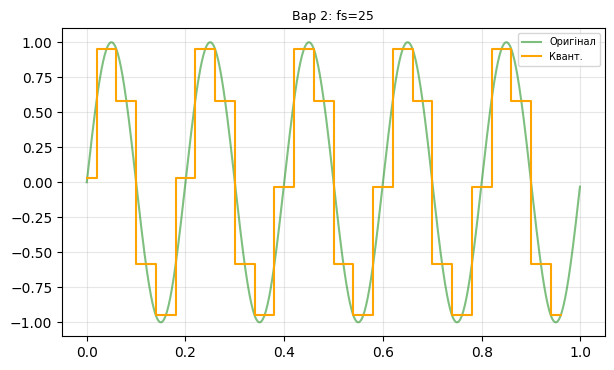
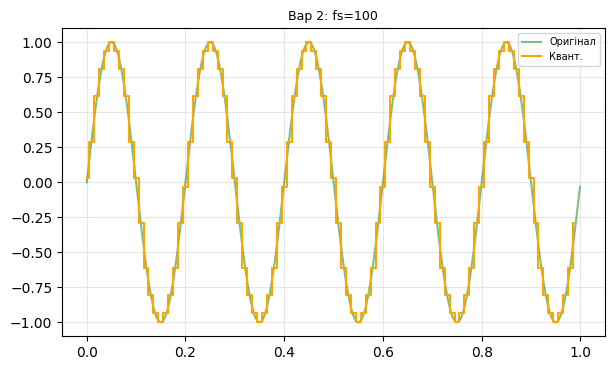
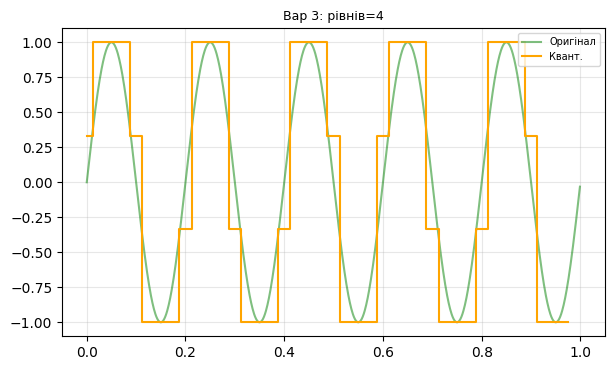
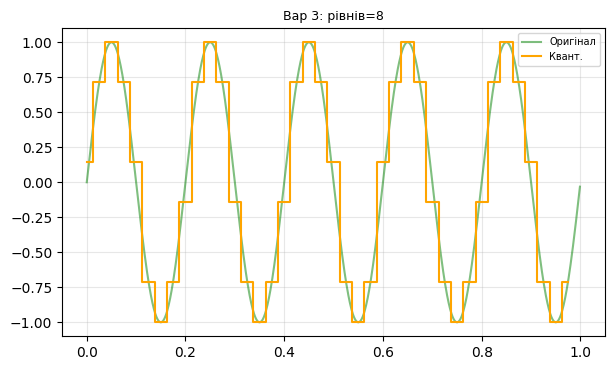
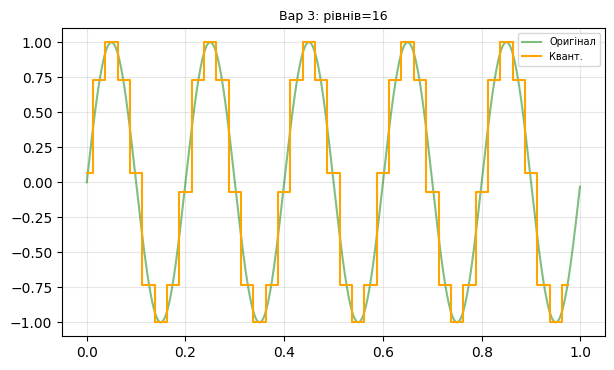
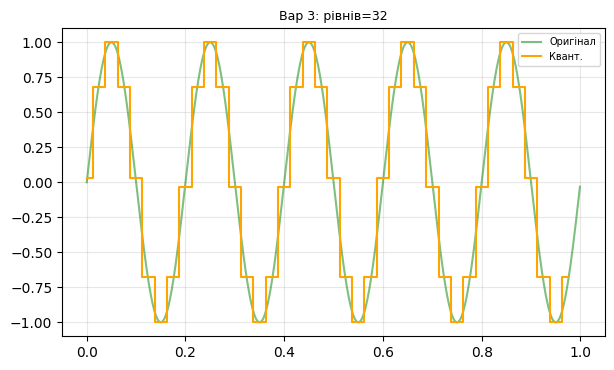
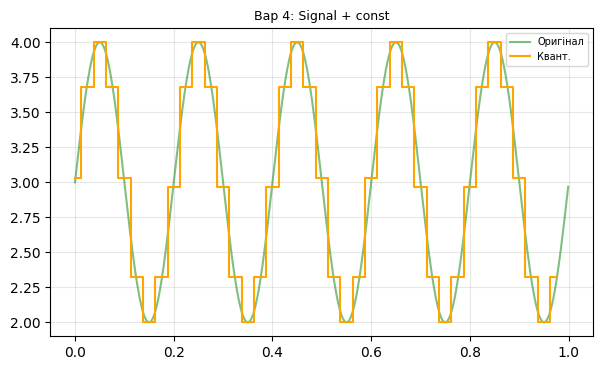
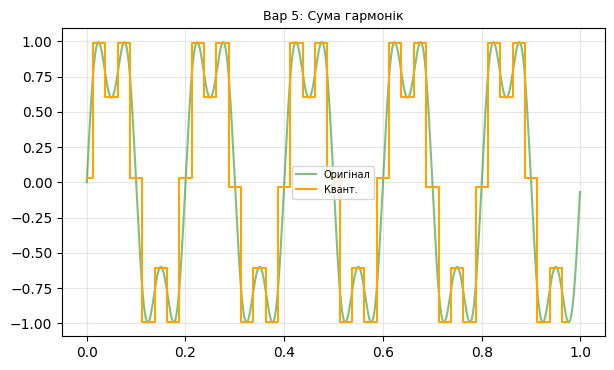
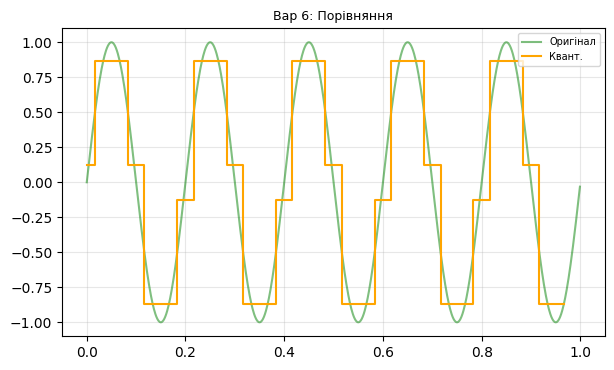
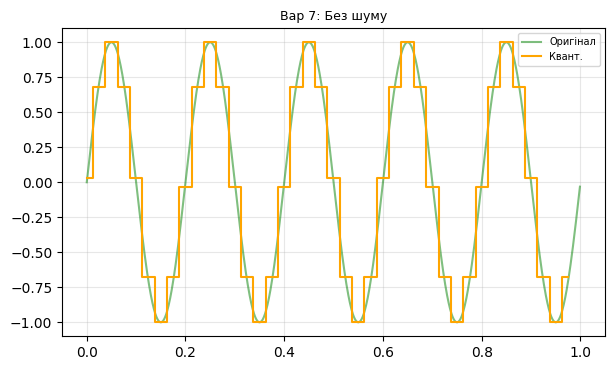
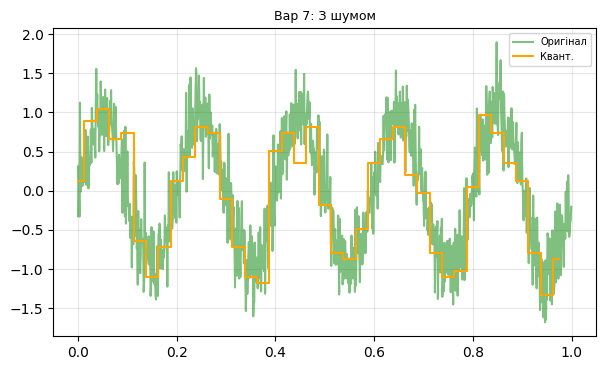
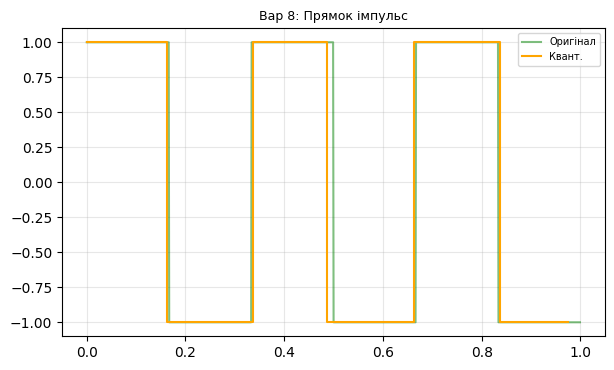
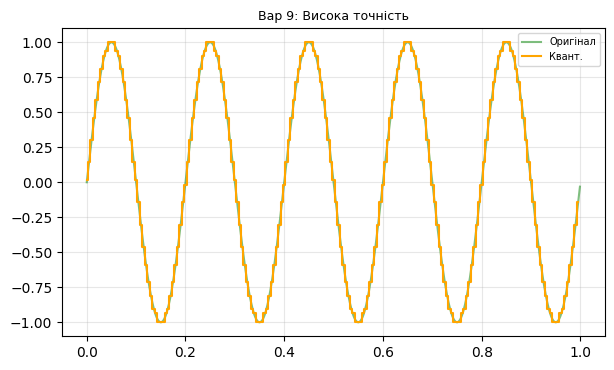

In [3]:
# --- ВИКОНАННЯ ЗАВДАНЬ ---

results_list = []

# Еталон для порівняння
results_list.append(process_signal("Еталон (5 Гц)", freqs=[5], fs=1000))

# Варіант 1. Виконати дослідження для синусоїдального сигналу з іншою частотою.
results_list.append(process_signal("Вар 1: Сигнал 10 Гц", freqs=[10], fs=1000))

# Варіант 2. Порівняти результати дискретизації для трьох різних частот дискретизації. (fs)
for fs_val in [12, 25, 100]:
  results_list.append(process_signal(f"Вар 2: fs={fs_val}", fs=fs_val))

# Варіант 3. Дослідити вплив кількості рівнів квантування 4, 8, 16 та 32.
for L in [4, 8, 16, 32]:
    results_list.append(process_signal(f"Вар 3: рівнів={L}", levels=L))

# Варіант 4. Додати до сигналу постійну складову та оцінити зміну середнього значення.
results_list.append(process_signal(f"Вар 4: Signal + const", const = 3))

# Варіант 5. Сума двох гармонік
results_list.append(process_signal("Вар 5: Сума гармонік", freqs=[5, 15], amps=[1, 0.4]))

# Варіант 6. Порівняння (в таблиці будуть колонки RMS Quant та RMS Orig)
results_list.append(process_signal("Вар 6: Порівняння", fs=30, levels=8))

# Варіант 7. Додавання шуму
results_list.append(process_signal("Вар 7: Без шуму", noise=0))
results_list.append(process_signal("Вар 7: З шумом", noise=0.3))

# Варіант 8. Прямокутний імпульс
results_list.append(process_signal("Вар 8: Прямок імпульс", sig_type='square', freqs=[3]))

# Варіант 9. Похибка (вже включена в кожний рядок як MSE Error)
results_list.append(process_signal("Вар 9: Висока точність", fs=200, levels=64))

# --- СТВОРЕННЯ ТАБЛИЦІ
df = pd.DataFrame(results_list)
HTML(df.to_html(escape=False))